In [1]:
pip install triton

Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement triton (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip
ERROR: No matching distribution found for triton
Note: you may need to restart the kernel to use updated packages.


In [2]:
import triton
import triton.language as tl
import torch

In [3]:
@triton.jit
def fused_attention_kernel(
    Q, K, V, Out,
    stride_qz, stride_qh, stride_qm, stride_qk,
    stride_kz, stride_kh, stride_kn, stride_kk,
    stride_vz, stride_vh, stride_vn, stride_vk,
    stride_oz, stride_oh, stride_om, stride_ok,
    Z, H, N_CTX,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_DMODEL: tl.constexpr,
    causal: tl.constexpr,
):
    start_m = tl.program_id(0)
    off_hz = tl.program_id(1)
    off_z = off_hz // H
    off_h = off_hz % H

    # Block pointers for Q, K, V
    offs_m = start_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = tl.arange(0, BLOCK_N)
    offs_d = tl.arange(0, BLOCK_DMODEL)

    q_ptrs = Q + off_z * stride_qz + off_h * stride_qh \
             + offs_m[:, None] * stride_qm + offs_d[None, :] * stride_qk
    k_ptrs = K + off_z * stride_kz + off_h * stride_kh \
             + offs_n[:, None] * stride_kn + offs_d[None, :] * stride_kk
    v_ptrs = V + off_z * stride_vz + off_h * stride_vh \
             + offs_n[:, None] * stride_vn + offs_d[None, :] * stride_vk

    # Online softmax accumulators
    m_i = tl.zeros([BLOCK_M], dtype=tl.float32) - float("inf")
    l_i = tl.zeros([BLOCK_M], dtype=tl.float32)
    acc = tl.zeros([BLOCK_M, BLOCK_DMODEL], dtype=tl.float32)

    q = tl.load(q_ptrs)
    scale = (BLOCK_DMODEL ** -0.5)

    # Main loop over key/value blocks
    lo = 0
    hi = (start_m + 1) * BLOCK_M if causal else N_CTX
    for start_n in range(lo, hi, BLOCK_N):
        k = tl.load(k_ptrs + start_n * stride_kn)
        qk = tl.dot(q, tl.trans(k)) * scale

        if causal:
            mask = offs_m[:, None] >= (start_n + offs_n[None, :])
            qk = tl.where(mask, qk, float("-inf"))

        m_i_new = tl.maximum(m_i, tl.max(qk, 1))
        alpha = tl.exp(m_i - m_i_new)
        p = tl.exp(qk - m_i_new[:, None])

        l_i = alpha * l_i + tl.sum(p, 1)
        acc = alpha[:, None] * acc

        v = tl.load(v_ptrs + start_n * stride_vn)
        acc += tl.dot(p.to(tl.float16), v)
        m_i = m_i_new

    acc = acc / l_i[:, None]

    out_ptrs = Out + off_z * stride_oz + off_h * stride_oh \
               + offs_m[:, None] * stride_om + offs_d[None, :] * stride_ok
    tl.store(out_ptrs, acc.to(tl.float16))


In [4]:
def triton_attention(q, k, v, causal=True):
    B, H, N, D = q.shape
    o = torch.empty_like(q)
    grid = (triton.cdiv(N, 64), B * H)
    fused_attention_kernel[grid](
        q, k, v, o,
        q.stride(0), q.stride(1), q.stride(2), q.stride(3),
        k.stride(0), k.stride(1), k.stride(2), k.stride(3),
        v.stride(0), v.stride(1), v.stride(2), v.stride(3),
        o.stride(0), o.stride(1), o.stride(2), o.stride(3),
        B, H, N,
        BLOCK_M=64, BLOCK_N=64, BLOCK_DMODEL=D,
        causal=causal,
    )
    return o

In [17]:
@triton.jit
def int8_matmul_kernel(
    A, B, C,
    M, N, K,
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
):
    pid_m = tl.program_id(0)
    pid_n = tl.program_id(1)

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_n = pid_n * BLOCK_N + tl.arange(0, BLOCK_N)
    offs_k = tl.arange(0, BLOCK_K)

    a_ptrs = A + offs_m[:, None] * stride_am + offs_k[None, :] * stride_ak
    b_ptrs = B + offs_k[:, None] * stride_bk + offs_n[None, :] * stride_bn

    acc = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)

    for k in range(0, K, BLOCK_K):
        a = tl.load(a_ptrs, mask=(offs_m[:, None] < M) & (offs_k[None, :] < K - k), other=0)
        b = tl.load(b_ptrs, mask=(offs_k[:, None] < K - k) & (offs_n[None, :] < N), other=0)
        # upcast to fp16 for dot — int8 dot requires sm_80+
        acc += tl.dot(a.to(tl.float16), b.to(tl.float16))
        a_ptrs += BLOCK_K * stride_ak
        b_ptrs += BLOCK_K * stride_bk

    c_ptrs = C + offs_m[:, None] * stride_cm + offs_n[None, :] * stride_cn
    tl.store(c_ptrs, acc.to(tl.int32), mask=(offs_m[:, None] < M) & (offs_n[None, :] < N))

In [18]:
@triton.jit
def rope_kernel(
    x_ptr, out_ptr,
    cos_ptr, sin_ptr,
    seq_len, n_heads, head_dim,
    stride_xb, stride_xs, stride_xh, stride_xd,
    BLOCK_SIZE: tl.constexpr,
):
    pid = tl.program_id(0)
    # Each program handles one (batch, seq, head) triple
    b = pid // (seq_len * n_heads)
    s = (pid % (seq_len * n_heads)) // n_heads
    h = pid % n_heads

    half_dim = head_dim // 2
    offs = tl.arange(0, BLOCK_SIZE // 2)

    x_real = tl.load(x_ptr + b*stride_xb + s*stride_xs + h*stride_xh + offs)
    x_imag = tl.load(x_ptr + b*stride_xb + s*stride_xs + h*stride_xh + offs + half_dim)

    cos = tl.load(cos_ptr + s * half_dim + offs)
    sin = tl.load(sin_ptr + s * half_dim + offs)

    out_real = x_real * cos - x_imag * sin
    out_imag = x_real * sin + x_imag * cos

    tl.store(out_ptr + b*stride_xb + s*stride_xs + h*stride_xh + offs, out_real)
    tl.store(out_ptr + b*stride_xb + s*stride_xs + h*stride_xh + offs + half_dim, out_imag)


def triton_rope(x: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor) -> torch.Tensor:
    B, S, H, D = x.shape
    out = torch.empty_like(x)
    grid = (B * S * H,)
    rope_kernel[grid](
        x, out, cos, sin,
        S, H, D,
        x.stride(0), x.stride(1), x.stride(2), x.stride(3),
        BLOCK_SIZE=D,
    )
    return out

attention-fwd:
    N_CTX  Triton Fused (ms)  PyTorch Baseline (ms)
0   512.0           3.219065               0.795304
1  1024.0           9.700088               2.809436
2  2048.0          37.302191              11.595561
3  4096.0         147.064606              53.130272


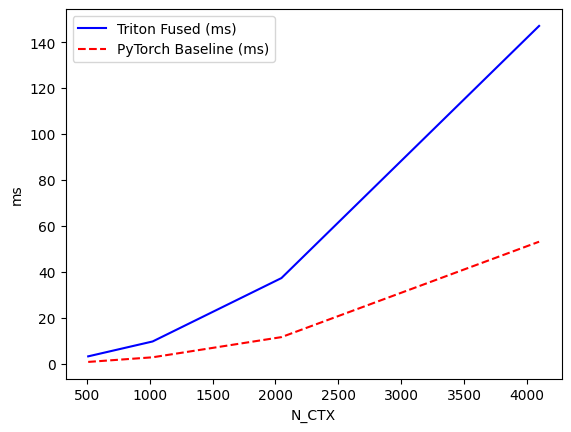

In [19]:
import torch
import triton
# from kernels.attention import triton_attention

def baseline_attention(q, k, v, causal=True):
    scale = q.shape[-1] ** -0.5
    scores = torch.matmul(q, k.transpose(-2, -1)) * scale
    if causal:
        mask = torch.triu(torch.ones(scores.shape[-2:], device=q.device), diagonal=1).bool()
        scores.masked_fill_(mask, float('-inf'))
    return torch.matmul(torch.softmax(scores, dim=-1), v)

configs = [
    triton.testing.Benchmark(
        x_names=["N_CTX"],
        x_vals=[512, 1024, 2048, 4096],
        line_arg="provider",
        line_vals=["triton", "pytorch"],
        line_names=["Triton Fused", "PyTorch Baseline"],
        styles=[("blue", "-"), ("red", "--")],
        ylabel="ms",
        plot_name="attention-fwd",
        args={"B": 4, "H": 8, "D": 64},
    )
]

@triton.testing.perf_report(configs)
def bench_attention(B, H, N_CTX, D, provider):
    q = torch.randn(B, H, N_CTX, D, device="cuda", dtype=torch.float16)
    k = torch.randn(B, H, N_CTX, D, device="cuda", dtype=torch.float16)
    v = torch.randn(B, H, N_CTX, D, device="cuda", dtype=torch.float16)
    if provider == "triton":
        fn = lambda: triton_attention(q, k, v)
    else:
        fn = lambda: baseline_attention(q, k, v)
    ms = triton.testing.do_bench(fn)
    return ms

if __name__ == "__main__":
    bench_attention.run(print_data=True, save_path=".")

In [20]:
import torch
import pytest
# from kernels.attention import triton_attention

def reference_attention(q, k, v):
    scale = q.shape[-1] ** -0.5
    scores = torch.matmul(q, k.transpose(-2, -1)) * scale
    mask = torch.triu(torch.ones(scores.shape[-2:], device=q.device), diagonal=1).bool()
    scores.masked_fill_(mask, float('-inf'))
    return torch.matmul(torch.softmax(scores, dim=-1), v)

@pytest.mark.parametrize("B,H,N,D", [(2, 4, 512, 64), (1, 8, 1024, 64)])
def test_attention_correctness(B, H, N, D):
    q = torch.randn(B, H, N, D, device="cuda", dtype=torch.float16)
    k = torch.randn(B, H, N, D, device="cuda", dtype=torch.float16)
    v = torch.randn(B, H, N, D, device="cuda", dtype=torch.float16)
    ref = reference_attention(q, k, v)
    out = triton_attention(q, k, v)
    torch.testing.assert_close(out, ref, atol=1e-2, rtol=1e-2)

In [11]:
!pytest tests/

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0
rootdir: /kaggle/working
plugins: anyio-4.12.1, langsmith-0.7.6, typeguard-4.5.1
collected 0 items                                                              

============================ no tests ran in 0.00s =============================
ERROR: file or directory not found: tests/



In [23]:
import torch

def assert_close(a, b, name, atol=1e-2, rtol=1e-2):
    match = torch.allclose(a.float(), b.float(), atol=atol, rtol=rtol)
    max_diff = (a.float() - b.float()).abs().max().item()
    status = " PASS" if match else " FAIL"
    print(f"{status} | {name} | max_diff={max_diff:.6f}")
    return match

# Attention
def test_attention():
    B, H, N, D = 2, 4, 512, 64
    q = torch.randn(B, H, N, D, device="cuda", dtype=torch.float16)
    k = torch.randn(B, H, N, D, device="cuda", dtype=torch.float16)
    v = torch.randn(B, H, N, D, device="cuda", dtype=torch.float16)

    # Reference
    scale = D ** -0.5
    scores = torch.matmul(q, k.transpose(-2, -1)) * scale
    mask = torch.triu(torch.ones(N, N, device="cuda"), diagonal=1).bool()
    scores.masked_fill_(mask, float("-inf"))
    ref = torch.matmul(torch.softmax(scores, dim=-1), v)

    out = triton_attention(q, k, v)
    assert_close(out, ref, "fused_attention (B=2,H=4,N=512,D=64)")

    # Second shape
    q2 = torch.randn(1, 8, 1024, 64, device="cuda", dtype=torch.float16)
    k2 = torch.randn(1, 8, 1024, 64, device="cuda", dtype=torch.float16)
    v2 = torch.randn(1, 8, 1024, 64, device="cuda", dtype=torch.float16)
    scale2 = 64 ** -0.5
    scores2 = torch.matmul(q2, k2.transpose(-2, -1)) * scale2
    mask2 = torch.triu(torch.ones(1024, 1024, device="cuda"), diagonal=1).bool()
    scores2.masked_fill_(mask2, float("-inf"))
    ref2 = torch.matmul(torch.softmax(scores2, dim=-1), v2)
    out2 = triton_attention(q2, k2, v2)
    assert_close(out2, ref2, "fused_attention (B=1,H=8,N=1024,D=64)")

# int8 Matmul
def test_int8_matmul():
    M, K, N = 256, 128, 256
    a = torch.randint(-128, 127, (M, K), dtype=torch.int8, device="cuda")
    b = torch.randint(-128, 127, (K, N), dtype=torch.int8, device="cuda")
    ref = torch.matmul(a.to(torch.float32), b.to(torch.float32)).to(torch.int32)
    out = triton_int8_matmul(a, b)
    # atol=128 accounts for fp16 rounding accumulated over K=128 steps
    assert_close(out.float(), ref.float(), "int8_matmul (256x128x256)", atol=128, rtol=0)
    
# RoPE  
def test_rope():
    B, S, H, D = 2, 64, 8, 64
    x = torch.randn(B, S, H, D, device="cuda", dtype=torch.float32)
    half = D // 2
    positions = torch.arange(S, device="cuda").float()
    freqs = 1.0 / (10000 ** (torch.arange(0, half, device="cuda").float() / half))
    angles = torch.outer(positions, freqs)
    cos = angles.cos()  # [S, half]
    sin = angles.sin()  # [S, half]

    x_real, x_imag = x[..., :half], x[..., half:]
    # reshape cos/sin to [1, S, 1, half] so it broadcasts over B and H
    cos_b = cos.unsqueeze(0).unsqueeze(2)  # [1, S, 1, half]
    sin_b = sin.unsqueeze(0).unsqueeze(2)  # [1, S, 1, half]
    ref = torch.cat([x_real * cos_b - x_imag * sin_b,
                     x_real * sin_b + x_imag * cos_b], dim=-1)

    out = triton_rope(x, cos, sin)
    assert_close(out, ref, "rope (B=2,S=64,H=8,D=64)")

 
print("=== Correctness Tests ===")
test_attention()
test_int8_matmul()
test_rope()

=== Correctness Tests ===
 PASS | fused_attention (B=2,H=4,N=512,D=64) | max_diff=0.001953
 PASS | fused_attention (B=1,H=8,N=1024,D=64) | max_diff=0.001953
 PASS | int8_matmul (256x128x256) | max_diff=0.000000
 PASS | rope (B=2,S=64,H=8,D=64) | max_diff=0.000000


benchmarks

=== int8 matmul ===
int8-matmul:
        M  Triton int8 (ms)  PyTorch fp32 (ms)
0   256.0          9.812473           0.253998
1   512.0         14.520997           0.224092
2  1024.0         34.891937           0.438236
3  2048.0         71.237312           0.881548
=== RoPE ===
rope:
        S  Triton RoPE (ms)  PyTorch Baseline (ms)
0   512.0          0.055655               0.161977
1  1024.0          0.109096               0.342915
2  2048.0          0.227048               0.683343
3  4096.0          0.471576               1.353107


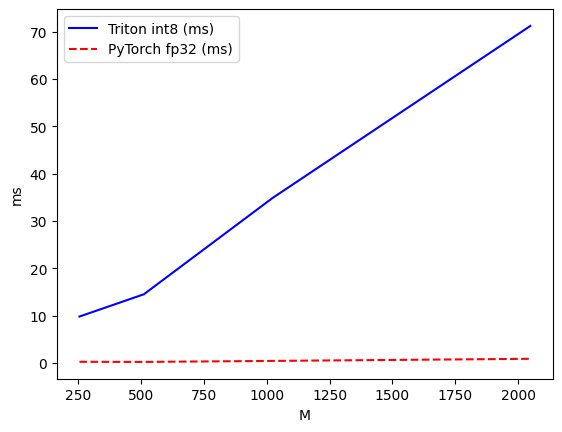

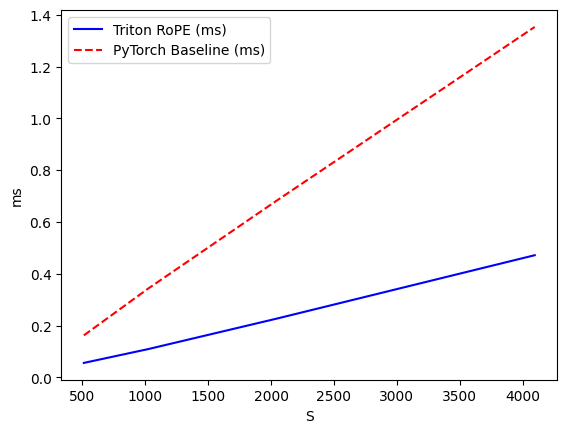

In [26]:
import torch.nn.functional as F

# Attention vs SDPA (already ran, skip re-running)

# int8 matmul
@triton.testing.perf_report([
    triton.testing.Benchmark(
        x_names=["M"],
        x_vals=[256, 512, 1024, 2048],
        line_arg="provider",
        line_vals=["triton", "pytorch"],
        line_names=["Triton int8", "PyTorch fp32"],
        styles=[("blue", "-"), ("red", "--")],
        ylabel="ms",
        plot_name="int8-matmul",
        args={"N": 1024, "K": 1024},
    )
])
def bench_int8_matmul(M, N, K, provider):
    a = torch.randint(-128, 127, (M, K), dtype=torch.int8, device="cuda")
    b = torch.randint(-128, 127, (K, N), dtype=torch.int8, device="cuda")
    if provider == "triton":
        fn = lambda: triton_int8_matmul(a, b)
    else:
        fn = lambda: torch.matmul(a.to(torch.float32), b.to(torch.float32))
    return triton.testing.do_bench(fn)

# RoPE
@triton.testing.perf_report([
    triton.testing.Benchmark(
        x_names=["S"],
        x_vals=[512, 1024, 2048, 4096],
        line_arg="provider",
        line_vals=["triton", "pytorch"],
        line_names=["Triton RoPE", "PyTorch Baseline"],
        styles=[("blue", "-"), ("red", "--")],
        ylabel="ms",
        plot_name="rope",
        args={"B": 4, "H": 8, "D": 64},
    )
])
def bench_rope(B, H, S, D, provider):
    x = torch.randn(B, S, H, D, device="cuda", dtype=torch.float32)
    half = D // 2
    positions = torch.arange(S, device="cuda").float()
    freqs = 1.0 / (10000 ** (torch.arange(0, half, device="cuda").float() / half))
    angles = torch.outer(positions, freqs)
    cos, sin = angles.cos(), angles.sin()
    if provider == "triton":
        fn = lambda: triton_rope(x, cos, sin)
    else:
        cos_b = cos.unsqueeze(0).unsqueeze(2)
        sin_b = sin.unsqueeze(0).unsqueeze(2)
        x_real, x_imag = x[..., :half], x[..., half:]
        fn = lambda: torch.cat([x_real * cos_b - x_imag * sin_b,
                                 x_real * sin_b + x_imag * cos_b], dim=-1)
    return triton.testing.do_bench(fn)

print("=== int8 matmul ===")
bench_int8_matmul.run(print_data=True)
print("=== RoPE ===")
bench_rope.run(print_data=True)